In [2]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

os.makedirs("../figures/eda", exist_ok=True)

pd.set_option("display.max_columns", 100)

### Downloading Price dataset

In [120]:
### We are downloading data for the given period between start_date and end_date

import time
import requests
import pandas as pd
from datetime import timedelta


def get_price_data(start_date, end_date, source_url, page_size=5000, sleep=0.2):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    date_ranges = []
    current = start_date

    while current <= end_date:
        week_end = current + timedelta(days=6)
        if week_end > end_date:
            week_end = end_date

        date_ranges.append((current, week_end))
        current = week_end + timedelta(days=1)

    all_price_data = []

    for start, end in date_ranges:
        page = 1

        while True:
            params = {
                "from": start.strftime("%Y-%m-%d"),
                "to": end.strftime("%Y-%m-%d"),
                "format": "json",
                "page": page,
                "pageSize": page_size,
            }

            try:
                r = requests.get(source_url, params=params)
                r.raise_for_status()
                data = r.json()

                records = data.get("data", [])

                if not records:
                    break

                df = pd.json_normalize(records)
                all_price_data.append(df)

                print(
                    f"Downloaded {len(df)} rows "
                    f"for {start.date()} to {end.date()} | page {page}"
                )

                # Stop if this is the last page
                if len(df) < page_size:
                    break

                page += 1
                time.sleep(sleep)

            except Exception as e:
                print(f"Error for {start.date()} to {end.date()}, page {page}: {e}")
                break

    price_df = pd.concat(all_price_data, ignore_index=True)

    price_df["settlementDate"] = pd.to_datetime(price_df["settlementDate"])
    price_df["startTime"] = pd.to_datetime(price_df["startTime"])

    return price_df

price_df = get_price_data("2023-01-01", "2024-12-31", source_url="https://data.elexon.co.uk/bmrs/api/v1/balancing/pricing/market-index")
price_df.head(10)

Downloaded 578 rows for 2023-01-01 to 2023-01-07 | page 1
Downloaded 576 rows for 2023-01-08 to 2023-01-14 | page 1
Downloaded 578 rows for 2023-01-15 to 2023-01-21 | page 1
Downloaded 574 rows for 2023-01-22 to 2023-01-28 | page 1
Downloaded 578 rows for 2023-01-29 to 2023-02-04 | page 1
Downloaded 576 rows for 2023-02-05 to 2023-02-11 | page 1
Downloaded 578 rows for 2023-02-12 to 2023-02-18 | page 1
Downloaded 578 rows for 2023-02-19 to 2023-02-25 | page 1
Downloaded 578 rows for 2023-02-26 to 2023-03-04 | page 1
Downloaded 578 rows for 2023-03-05 to 2023-03-11 | page 1
Downloaded 578 rows for 2023-03-12 to 2023-03-18 | page 1
Downloaded 576 rows for 2023-03-19 to 2023-03-25 | page 1
Downloaded 578 rows for 2023-03-26 to 2023-04-01 | page 1
Downloaded 578 rows for 2023-04-02 to 2023-04-08 | page 1
Downloaded 578 rows for 2023-04-09 to 2023-04-15 | page 1
Downloaded 577 rows for 2023-04-16 to 2023-04-22 | page 1
Downloaded 578 rows for 2023-04-23 to 2023-04-29 | page 1
Downloaded 578

,startTime,dataProvider,settlementDate,settlementPeriod,price,volume
0,2023-01-07 00:00:00+00:00,APXMIDP,2023-01-07,1,3.22,853.05
1,2023-01-07 00:00:00+00:00,N2EXMIDP,2023-01-07,1,0.00,0.00
2,2023-01-06 23:30:00+00:00,APXMIDP,2023-01-06,48,20.32,789.90
3,2023-01-06 23:30:00+00:00,N2EXMIDP,2023-01-06,48,0.00,0.00
4,2023-01-06 23:00:00+00:00,APXMIDP,2023-01-06,47,71.31,1048.30
5,2023-01-06 23:00:00+00:00,N2EXMIDP,2023-01-06,47,0.00,0.00
6,2023-01-06 22:30:00+00:00,APXMIDP,2023-01-06,46,72.92,1698.70
7,2023-01-06 22:30:00+00:00,N2EXMIDP,2023-01-06,46,0.00,0.00
8,2023-01-06 22:00:00+00:00,APXMIDP,2023-01-06,45,83.47,1765.10
9,2023-01-06 22:00:00+00:00,N2EXMIDP,2023-01-06,45,0.00,0.00


In [121]:
timestamp_col = "settlementDate"
price_col = "price"
price_df[timestamp_col] = pd.to_datetime(price_df[timestamp_col])
price_df = price_df.sort_values(timestamp_col).reset_index(drop=True)
print("Shape:", price_df.shape)

Shape: (60219, 6)


In [52]:
print(price_df["price"].describe())

count    60219.000000
mean        41.869590
std         49.515067
min        -77.290000
25%          0.000000
50%          0.000000
75%         81.950000
max        605.170000
Name: price, dtype: float64


In [54]:
zero_prices = (price_df["price"] == 0).sum()

print(f"Zero-price observations: {zero_prices}")
print(f"Percentage: {zero_prices/len(price_df)*100:.2f}%")

Zero-price observations: 30017
Percentage: 49.85%


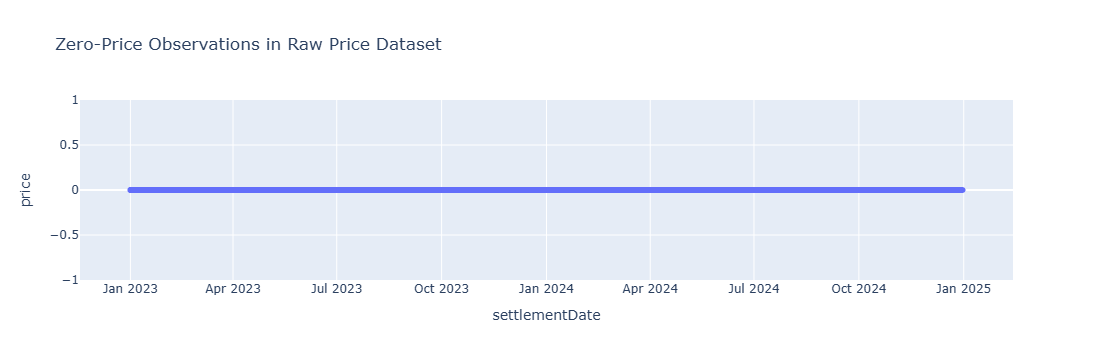

In [55]:
zeros = price_df[price_df["price"] == 0]

fig = px.scatter(
    zeros,
    x=timestamp_col,
    y="price",
    title="Zero-Price Observations in Raw Price Dataset"
)

fig.show()

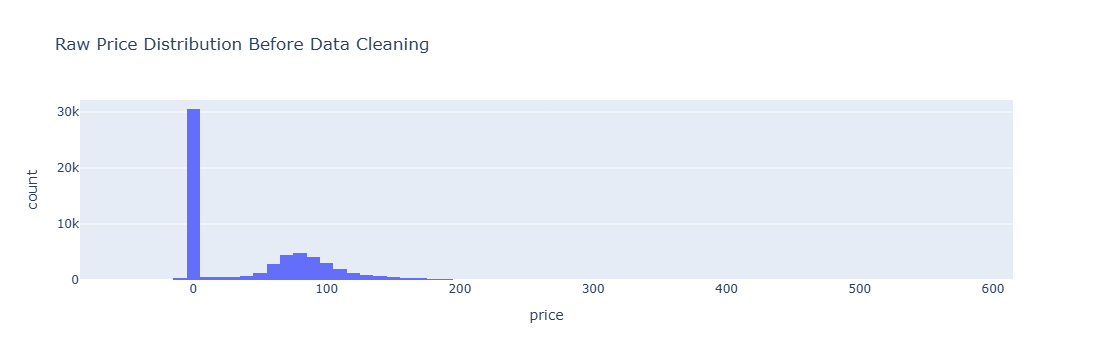

In [40]:
fig = px.histogram(
    price_df,
    x="price",
    nbins=100,
    title="Raw Price Distribution Before Data Cleaning"
)

fig.show()

### Data Quality Assessment

Initial inspection of the raw N2EX MIDP dataset revealed a number of observations where the reported market price was exactly £0/MWh.

These values do not represent genuine market-clearing prices but correspond to missing or invalid records within the source dataset. Including them would artificially distort the price distribution and bias summary statistics, resulting in:

Underestimation of the average electricity price
An unrealistic concentration of observations at zero
Potential degradation of model performance

Consequently, zero-price observations were removed prior to feature engineering and model training.

In [46]:
clean_price_df =  price_df[price_df['dataProvider'] == 'APXMIDP'].copy()
print(clean_price_df.shape

In [59]:
raw_stats = pd.DataFrame({
    "Dataset": ["price_df","clean_price_df"],
    "Mean Price":[
        price_df["price"].mean(),
        clean_price_df["price"].mean()
    ],
    "Median Price":[
        price_df["price"].median(),
        clean_price_df["price"].median()
    ],
    "Max Price":[
        price_df["price"].max(),
        clean_price_df["price"].max()
    ],
    "Min Price":[
        price_df["price"].min(),
        clean_price_df["price"].min()
    ],
    "Zero values":[
        (price_df["price"] == 0).sum(),
        (clean_price_df["price"] == 0).sum()
    ]
})
raw_stats

In [26]:
# Dataset overview
print("Date range:", price_df[timestamp_col].min(), "to", price_df[timestamp_col].max())
print("Number of days:", price_df[timestamp_col].dt.date.nunique())
print("Number of rows:", len(price_df))

overview = pd.DataFrame({
    "column": price_df.columns,
    "dtype": price_df.dtypes.astype(str).values,
    "missing_values": price_df.isna().sum().values,
    "missing_percent": (price_df.isna().mean() * 100).round(2).values,
    "unique_values": price_df.nunique().values
})

print(f"Price mean : £{price_df['price'].mean():.1f}/MWh")
print(f"Price range: £{price_df['price'].min():.1f} to £{price_df['price'].max():.1f}")

Shape: (60219, 6)
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
Number of days: 731
Number of rows: 60219
Price mean : £41.9/MWh
Price range: £-77.3 to £605.2


In [61]:
# Adding time based features

clean_price_df["date"] = price_df[timestamp_col].dt.date
clean_price_df["hour"] = price_df[timestamp_col].dt.hour
clean_price_df["minute"] = price_df[timestamp_col].dt.minute
clean_price_df["day_of_week"] = price_df[timestamp_col].dt.dayofweek
clean_price_df["day_name"] = price_df[timestamp_col].dt.day_name()
clean_price_df["month"] = price_df[timestamp_col].dt.month
clean_price_df["month_name"] = price_df[timestamp_col].dt.month_name()

# GB has 48 half-hourly settlement periods per day
clean_price_df["settlement_period"] = (
    clean_price_df[timestamp_col].dt.hour * 2
    + (clean_price_df[timestamp_col].dt.minute // 30)
    + 1
)

clean_price_df[[timestamp_col, price_col, "settlement_period", "hour", "day_name", "month_name"]].head()

,settlementDate,price,settlement_period,hour,day_name,month_name
1,2023-01-01,220.55,1,0,Sunday,January
3,2023-01-01,219.76,1,0,Sunday,January
5,2023-01-01,213.65,1,0,Sunday,January
7,2023-01-01,201.56,1,0,Sunday,January
9,2023-01-01,183.28,1,0,Sunday,January


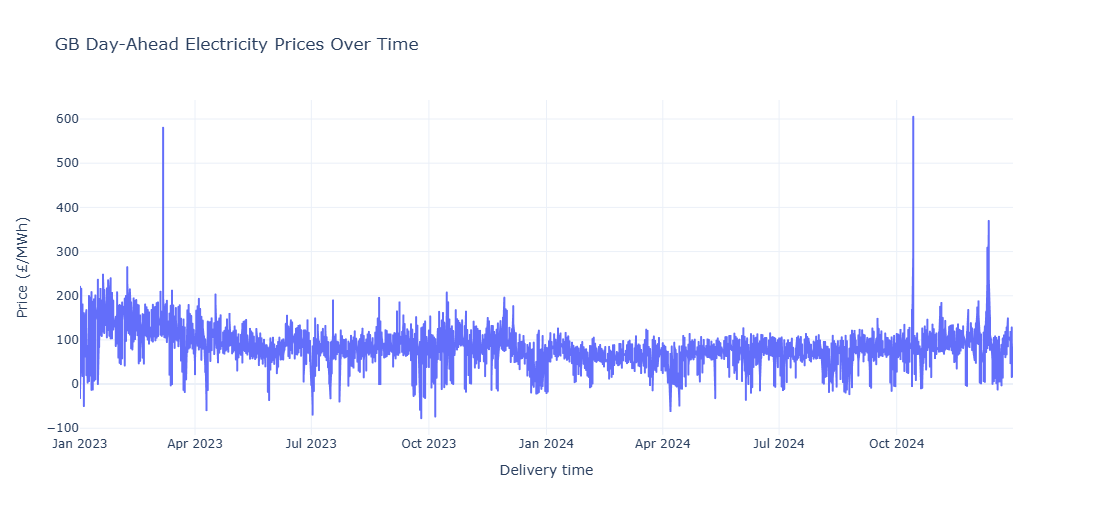

In [62]:
fig = px.line(
    clean_price_df,
    x=timestamp_col,
    y=price_col,
    title="GB Day-Ahead Electricity Prices Over Time",
    labels={
        timestamp_col: "Delivery time",
        price_col: "Price (£/MWh)"
    }
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=500,
    hovermode="x unified"
)

fig.show()

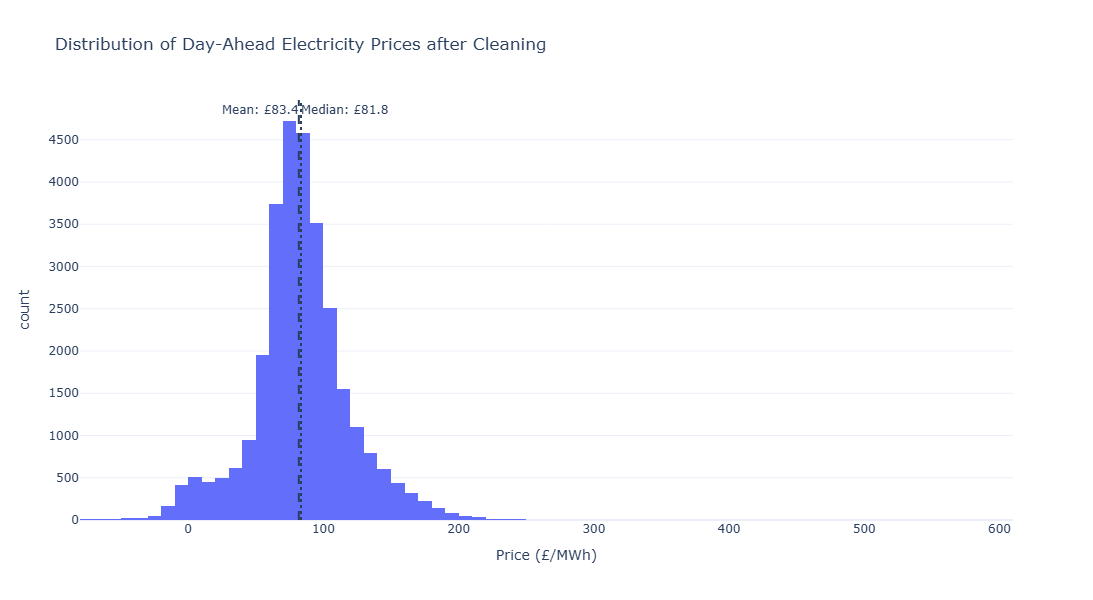

In [70]:
fig = px.histogram(
    clean_price_df,
    x=price_col,
    nbins=100,
    title="Distribution of Day-Ahead Electricity Prices after Cleaning",
    labels={
        price_col: "Price (£/MWh)",
        "count": "Number of settlement periods"
    }
)

fig.add_vline(
    x=clean_price_df[price_col].median(),
    line_dash="dash",
    annotation_text=f"Median: £{clean_price_df[price_col].median():.1f}",
    annotation_position="top right"
)

fig.add_vline(
    x=clean_price_df[price_col].mean(),
    line_dash="dot",
    annotation_text=f"Mean: £{clean_price_df[price_col].mean():.1f}",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=600
)

fig.show()

#### Note: Only invalid zero-price records were removed during preprocessing. Genuine market events, including negative prices and extreme positive price spikes, were retained to preserve the true characteristics of the wholesale electricity market.

#### The distribution is unimodal
- Most electricity prices are concentrated around £70–100/MWh, with the highest density around £80–90/MWh.
- This represents the "normal" operating conditions of the GB wholesale market.
#### The distribution is positively skewed (right-skewed)
- The long right tail extending beyond £200/MWh indicates that extreme price spikes occur, although infrequently.
- These spikes are typically associated with periods of high demand, low renewable generation, or system stress.
#### Negative prices exist but are rare
- The small left tail below £0/MWh reflects periods of oversupply, usually caused by high renewable generation combined with low electricity demand.
- Although uncommon, these events are characteristic of modern electricity markets and should be retained in the analysis.

#### Mean and median are very close

- Mean = £83.4/MWh
- Median = £81.8/MWh

The relatively small difference suggests that the bulk of the observations are concentrated around the centre of the distribution, while a limited number of extreme high-price events pull the mean slightly upward.

#### What this implier for modeling:
The electricity price distribution is highly non-Gaussian, with a long right tail caused by infrequent but extreme market events. While the majority of prices lie between approximately £50 and £120/MWh, occasional price spikes above £200/MWh create a forecasting challenge because these events are both rare and difficult to predict. This motivates evaluating model performance across different price regimes rather than relying solely on aggregate metrics such as MAE or RMSE.

In [66]:
price_summary = clean_price_df[price_col].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

price_summary

count    30149.000000
mean        83.443669
std         37.655865
min        -77.290000
1%          -9.810000
5%          16.192000
25%         65.520000
50%         81.840000
75%        101.200000
95%        147.026000
99%        185.218000
max        605.170000
Name: price, dtype: float64

In [67]:
negative_count = (clean_price_df[price_col] < 0).sum()
negative_pct = negative_count / len(price_df) * 100

p95 = clean_price_df[price_col].quantile(0.95)
p99 = clean_price_df[price_col].quantile(0.99)

spike_count = (clean_price_df[price_col] >= p99).sum()
spike_pct = spike_count / len(clean_price_df) * 100

print(f"Negative price periods: {negative_count} ({negative_pct:.2f}%)")
print(f"95th percentile price: £{p95:.2f}/MWh")
print(f"99th percentile price: £{p99:.2f}/MWh")
print(f"Spike periods above 99th percentile: {spike_count} ({spike_pct:.2f}%)")

Negative price periods: 714 (1.19%)
95th percentile price: £147.03/MWh
99th percentile price: £185.22/MWh
Spike periods above 99th percentile: 302 (1.00%)


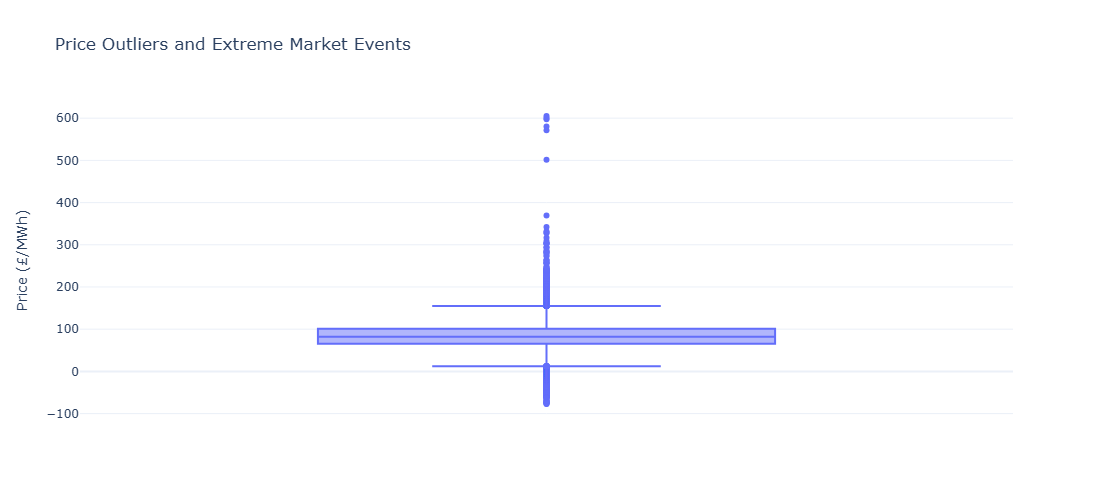

In [68]:
fig = px.box(
    clean_price_df,
    y=price_col,
    title="Price Outliers and Extreme Market Events",
    labels={price_col: "Price (£/MWh)"}
)

fig.update_layout(
    template="plotly_white",
    width=700,
    height=500
)

fig.show()

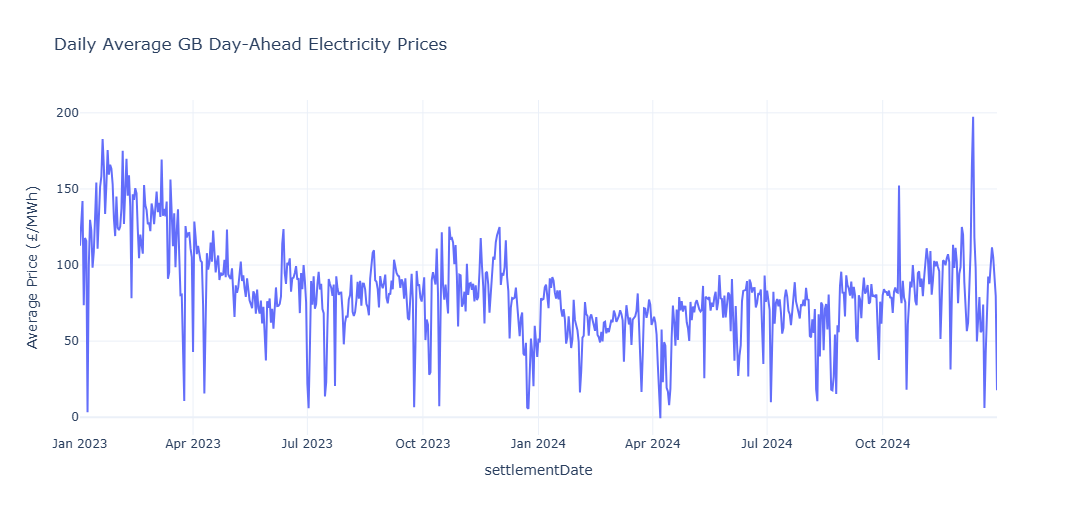

In [75]:
# Daily average price

daily_price = (
    clean_price_df
    .set_index("settlementDate")
    .resample("D")["price"]
    .mean()
    .reset_index()
)

fig = px.line(
    daily_price,
    x="settlementDate",
    y="price",
    title="Daily Average GB Day-Ahead Electricity Prices",
    labels={
        "timestamp": "Date",
        "price": "Average Price (£/MWh)"
    }
)

fig.update_layout(
    template="plotly_white",
    height=500,
    width=1100,
    hovermode="x unified"
)

fig.show()

# fig.write_html("../figures/eda/price/daily_average_price.html")

The daily average electricity price exhibits substantial variability over time, reflecting changing market conditions driven by demand, renewable generation, fuel prices, and seasonal effects. Although prices fluctuate considerably, periods of sustained higher and lower prices suggest that the market is not entirely random and contains temporal structure that can be exploited by forecasting models.

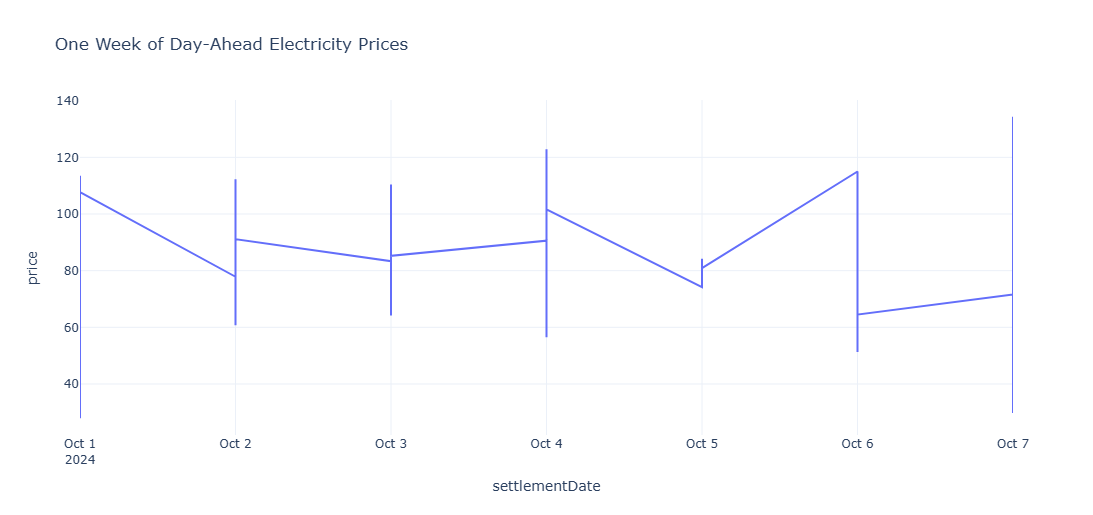

In [81]:
sample = clean_price_df[
    (clean_price_df["settlementDate"] >= "2024-10-01") &
    (clean_price_df["settlementDate"] < "2024-10-08")
]

fig = px.line(
    sample,
    x="settlementDate",
    y="price",
    title="One Week of Day-Ahead Electricity Prices"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    width=1100,
    hovermode="x unified"
)

fig.show()

A closer inspection of one representative week reveals clear intraday price dynamics, with recurring peaks and troughs across consecutive days. This indicates strong within-day seasonality, motivating the inclusion of temporal features such as settlement period, hour of day, and lagged prices during feature engineering.

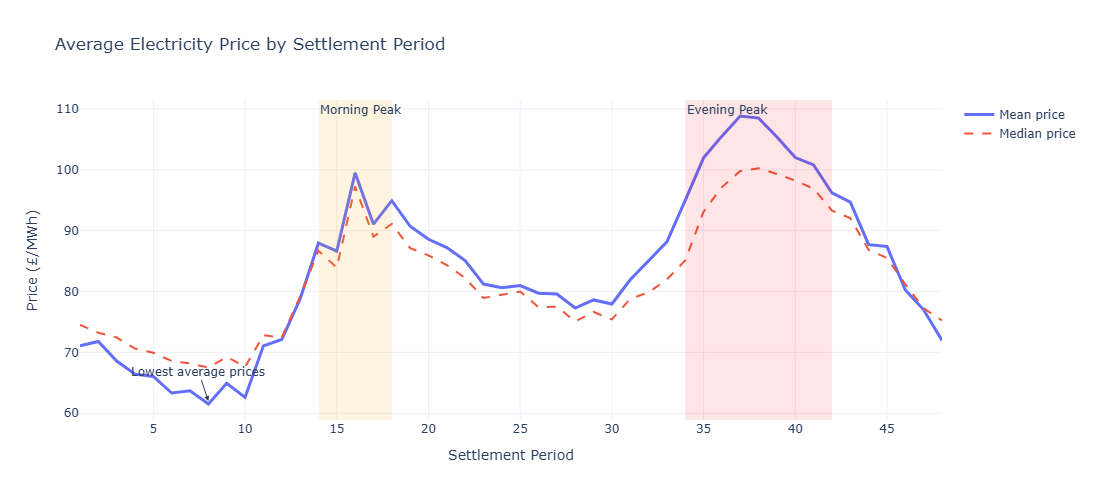

In [98]:
sp_profile = (
    clean_price_df[clean_price_df["settlementPeriod"]<=48]
    .groupby("settlementPeriod")["price"]
    .agg(
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=sp_profile["settlementPeriod"],
        y=sp_profile["mean"],
        mode="lines",
        name="Mean price",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=sp_profile["settlementPeriod"],
        y=sp_profile["median"],
        mode="lines",
        name="Median price",
        line=dict(width=2, dash="dash")
    )
)

fig.add_vrect(
    x0=14,
    x1=18,
    fillcolor="orange",
    opacity=0.12,
    line_width=0,
    annotation_text="Morning Peak",
    annotation_position="top left"
)

fig.add_vrect(
    x0=34,
    x1=42,
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="Evening Peak",
    annotation_position="top left"
)

fig.add_annotation(
    x=8,
    y=62,
    text="Lowest average prices",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    title="Average Electricity Price by Settlement Period",
    xaxis_title="Settlement Period",
    yaxis_title="Price (£/MWh)",
    hovermode="x unified",
    width=950,
    height=500
)

fig.show()

The average electricity price exhibits a strong intraday pattern across the 48 half-hour settlement periods. Prices are lowest during the early morning hours (Settlement Periods 5–10), when electricity demand is relatively low. Prices increase sharply during the morning demand ramp (Settlement Periods 14–18), followed by a brief decline during midday. A second and more pronounced peak occurs during the evening demand period (Settlement Periods 35–40), corresponding to increased residential electricity consumption after typical working hours.

The mean price is consistently higher than the median throughout most settlement periods, particularly during peak demand hours. This indicates that although the typical market price remains relatively stable, occasional high-price events increase the average price. Such behaviour is consistent with the positively skewed distribution observed earlier and highlights the influence of infrequent but extreme price spikes on the wholesale electricity market.

### Key Takeaways

- Electricity prices exhibit a clear and repeatable intraday cycle.
- The lowest average prices occur during overnight periods when electricity demand is lowest.
- Two demand-driven price peaks are visible during the morning and evening.
- Mean prices exceed median prices across most settlement periods, indicating the influence of occasional price spikes.
- These observations motivated the inclusion of temporal features such as settlement period, hour of day, and cyclical encodings in the forecasting model.

The heatmap shows that electricity prices vary systematically across both settlement periods and days of the week. The strongest price bands occur during morning and evening periods, while overnight settlement periods are consistently lower. Weekday patterns are generally more pronounced than weekend patterns, reflecting differences in electricity demand and market activity.

This supports the inclusion of temporal features such as settlement period, day of week, weekend flag, and cyclical encodings in the forecasting model.

## Price Autocorrelation

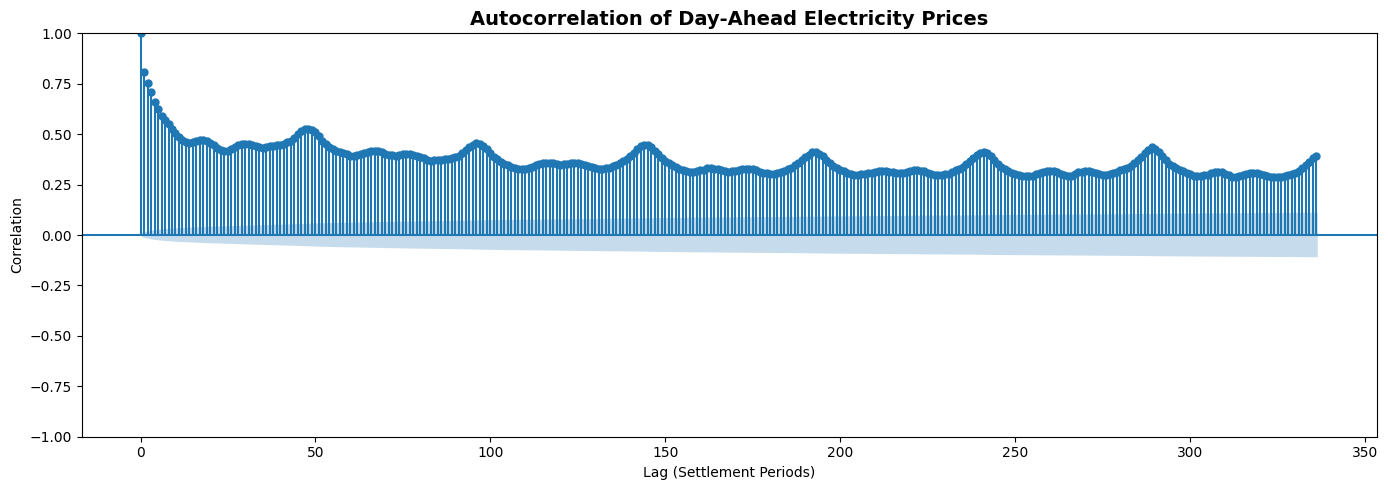

In [128]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,5))

plot_acf(
    clean_price_df["price"],
    lags=336,
    ax=ax
)

ax.set_title(
    "Autocorrelation of Day-Ahead Electricity Prices",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Lag (Settlement Periods)")
ax.set_ylabel("Correlation")

plt.tight_layout()
plt.show()

Electricity prices exhibit strong temporal dependence, with high autocorrelation at short lags and recurring peaks approximately every 48 settlement periods (24 hours). This indicates that prices are influenced by both recent observations and repeating daily market patterns. These findings motivated the inclusion of lag features such as lag-1, lag-48, and lag-336 (weekly lag) in the forecasting model.

## Correlation of Lag Features

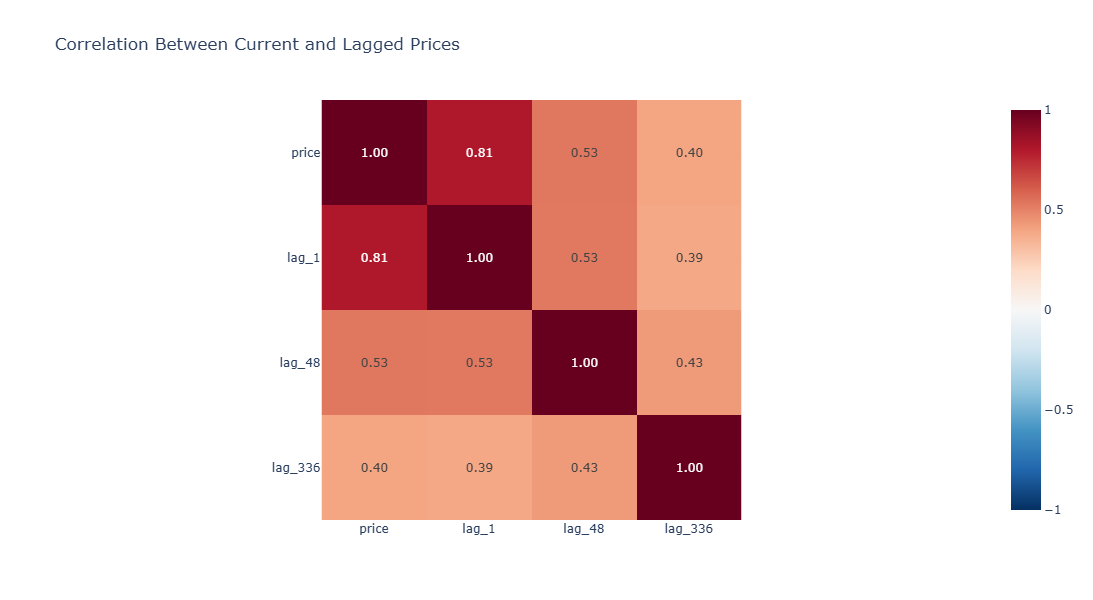

In [129]:
lag_df = clean_price_df.copy()

lag_df["lag_1"] = lag_df["price"].shift(1)
lag_df["lag_48"] = lag_df["price"].shift(48)
lag_df["lag_336"] = lag_df["price"].shift(336)

corr = lag_df[
    ["price","lag_1","lag_48","lag_336"]
].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Between Current and Lagged Prices"
)

fig.update_layout(
    template="plotly_white",
    width=700,
    height=600
)

fig.show()

Current electricity prices exhibit strong correlation with recent prices, particularly the previous settlement period and the same settlement period on the previous day. This confirms that lagged prices provide valuable predictive information and are among the most influential features in the forecasting model.

## Monthly Trend

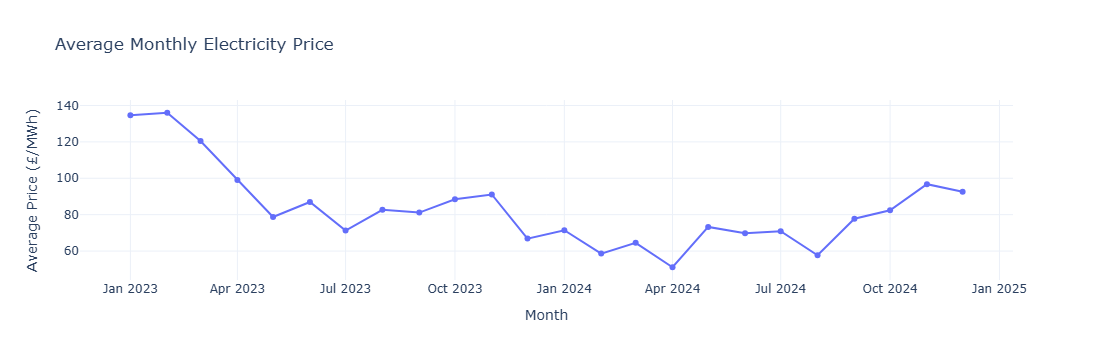

In [130]:
monthly = (
    clean_price_df
    .groupby(
        clean_price_df["settlementDate"].dt.to_period("M")
    )["price"]
    .mean()
    .reset_index()
)

monthly["settlementDate"] = monthly["settlementDate"].astype(str)

fig = px.line(
    monthly,
    x="settlementDate",
    y="price",
    markers=True,
    title="Average Monthly Electricity Price"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Average Price (£/MWh)"
)

fig.show()

Electricity prices show seasonal variation throughout the year, reflecting changing demand, renewable generation, and weather conditions. This observation motivated the inclusion of calendar-based features such as month and seasonal indicators.

## Negative Prices

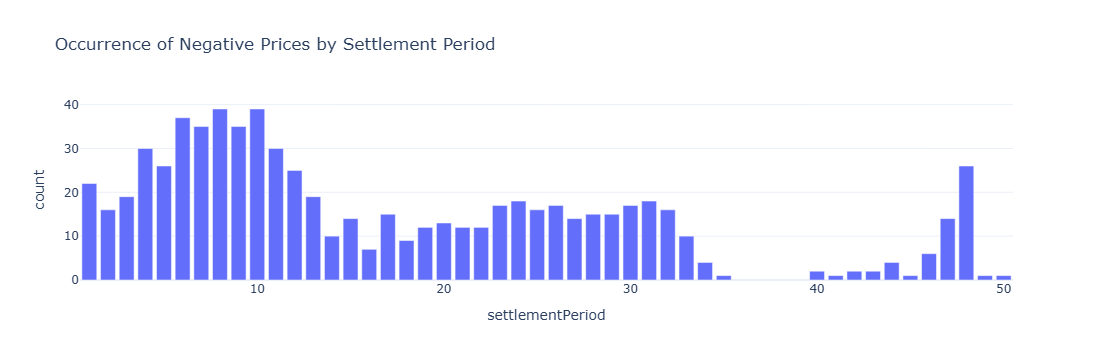

In [132]:
negative = (
    clean_price_df[clean_price_df["price"] < 0]
    .groupby("settlementPeriod")
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    negative,
    x="settlementPeriod",
    y="count",
    title="Occurrence of Negative Prices by Settlement Period"
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

Negative electricity prices occur infrequently but are concentrated during low-demand periods. These events are typically associated with periods of high renewable generation and system oversupply, making them challenging yet important cases for forecasting models.

| Observation               | Engineering Decision        |
| ------------------------- | --------------------------- |
| Right-skewed distribution | Evaluate by price regime    |
| Intraday seasonality      | Settlement period           |
| Strong autocorrelation    | Price lags                  |
| Monthly variation         | Month feature               |
| Rare negative prices      | Preserve rather than remove |
| Extreme spikes            | Non-linear model (XGBoost)  |
